In [58]:
# Import required libraries for numerical operations, plotting, statistics, and file handling
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rice, uniform, norm
from scipy import ndimage
import time
import os

In [59]:
# --- 1. SETUP: Paths, Metadata, and Helper Functions ---

# Define directories for images, ground truth, and parameter maps
IMAGE_DIR = '../images'
TARGET_DIR = '../target_lists'
PARAM_DIR = 'parameter_maps_6x9' # Directory to save/load MLE results

# Create parameter directory if it doesn't exist
if not os.path.exists(PARAM_DIR):
    os.makedirs(PARAM_DIR)

# --- Metadata for all 24 images ---
# Each dictionary contains metadata for a SAR image (mission, pass, heading, deployment, RFI flag, filename)
image_metadata = [
    # Mission 2: Deployment "Sigismund"
    {'mission': 2, 'pass': 1, 'heading': 225, 'deployment': 'Sigismund', 'rfi': 1, 'filename': 'v02_2_1_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 2, 'pass': 2, 'heading': 135, 'deployment': 'Sigismund', 'rfi': 0, 'filename': 'v02_2_2_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 2, 'pass': 3, 'heading': 225, 'deployment': 'Sigismund', 'rfi': 1, 'filename': 'v02_2_3_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 2, 'pass': 4, 'heading': 135, 'deployment': 'Sigismund', 'rfi': 0, 'filename': 'v02_2_4_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 2, 'pass': 5, 'heading': 230, 'deployment': 'Sigismund', 'rfi': 1, 'filename': 'v02_2_5_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 2, 'pass': 6, 'heading': 230, 'deployment': 'Sigismund', 'rfi': 1, 'filename': 'v02_2_6_1.a.Fbp.RFcorr.Geo.Magn'},
    # Mission 3: Deployment "Karl"
    {'mission': 3, 'pass': 1, 'heading': 225, 'deployment': 'Karl', 'rfi': 1, 'filename': 'v02_3_1_2.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 3, 'pass': 2, 'heading': 135, 'deployment': 'Karl', 'rfi': 0, 'filename': 'v02_3_2_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 3, 'pass': 3, 'heading': 225, 'deployment': 'Karl', 'rfi': 1, 'filename': 'v02_3_3_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 3, 'pass': 4, 'heading': 135, 'deployment': 'Karl', 'rfi': 0, 'filename': 'v02_3_4_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 3, 'pass': 5, 'heading': 230, 'deployment': 'Karl', 'rfi': 1, 'filename': 'v02_3_5_2.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 3, 'pass': 6, 'heading': 230, 'deployment': 'Karl', 'rfi': 1, 'filename': 'v02_3_6_1.a.Fbp.RFcorr.Geo.Magn'},
    # Mission 4: Deployment "Fredrik"
    {'mission': 4, 'pass': 1, 'heading': 225, 'deployment': 'Fredrik', 'rfi': 1, 'filename': 'v02_4_1_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 4, 'pass': 2, 'heading': 135, 'deployment': 'Fredrik', 'rfi': 0, 'filename': 'v02_4_2_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 4, 'pass': 3, 'heading': 225, 'deployment': 'Fredrik', 'rfi': 1, 'filename': 'v02_4_3_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 4, 'pass': 4, 'heading': 135, 'deployment': 'Fredrik', 'rfi': 0, 'filename': 'v02_4_4_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 4, 'pass': 5, 'heading': 230, 'deployment': 'Fredrik', 'rfi': 1, 'filename': 'v02_4_5_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 4, 'pass': 6, 'heading': 230, 'deployment': 'Fredrik', 'rfi': 1, 'filename': 'v02_4_6_1.a.Fbp.RFcorr.Geo.Magn'},
    # Mission 5: Deployment "Adolf-Fredrik"
    {'mission': 5, 'pass': 1, 'heading': 225, 'deployment': 'Adolf-Fredrik', 'rfi': 1, 'filename': 'v02_5_1_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 5, 'pass': 2, 'heading': 135, 'deployment': 'Adolf-Fredrik', 'rfi': 0, 'filename': 'v02_5_2_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 5, 'pass': 3, 'heading': 225, 'deployment': 'Adolf-Fredrik', 'rfi': 1, 'filename': 'v02_5_3_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 5, 'pass': 4, 'heading': 135, 'deployment': 'Adolf-Fredrik', 'rfi': 0, 'filename': 'v02_5_4_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 5, 'pass': 5, 'heading': 230, 'deployment': 'Adolf-Fredrik', 'rfi': 1, 'filename': 'v02_5_5_1.a.Fbp.RFcorr.Geo.Magn'},
    {'mission': 5, 'pass': 6, 'heading': 230, 'deployment': 'Adolf-Fredrik', 'rfi': 1, 'filename': 'v02_5_6_1.a.Fbp.RFcorr.Geo.Magn'},
]

# Small value to avoid division by zero
epsilon = 1e-9

# Function to load SAR image from binary file
def load_sar_image(filename, directory, rows=3000, cols=2000):
    filepath = os.path.join(directory, filename)
    image_data = np.fromfile(filepath, dtype='>f4').reshape((rows, cols))
    return image_data

# Function to load ground truth target pixel coordinates for a deployment
def load_ground_truth_pixels(deployment_name, target_dir):
    target_filename = deployment_name + ".Targets.txt"
    target_filepath = os.path.join(target_dir, target_filename)
    ground_truth_geo = np.loadtxt(target_filepath, usecols=(0, 1))
    Nmax, Emin = 7370488, 1653166
    ground_truth_pixels = []
    for north, east in ground_truth_geo:
        row = int(round(Nmax - north))
        col = int(round(east - Emin))
        ground_truth_pixels.append((row, col))
    return ground_truth_pixels

# Function to evaluate detection performance (Pd and FAR)
def evaluate_performance(detection_map, ground_truth_pixels):
    # Erode and dilate to clean up detection map
    eroded_map = ndimage.binary_erosion(detection_map)
    processed_map = ndimage.binary_dilation(eroded_map, iterations=2)
    labeled_map, num_objects = ndimage.label(processed_map)
    if num_objects == 0:
        return 0.0, 0.0
    # Find centers of detected objects
    detected_centers = ndimage.center_of_mass(processed_map, labeled_map, range(1, num_objects + 1))
    match_radius = 10.0
    true_positives = 0
    unmatched_detections = list(detected_centers)
    num_true_targets = len(ground_truth_pixels)
    # Match detected objects to ground truth targets
    for true_target_pos in ground_truth_pixels:
        for i, detected_pos in enumerate(unmatched_detections):
            distance = np.sqrt((true_target_pos[0] - detected_pos[0])**2 + (true_target_pos[1] - detected_pos[1])**2)
            if distance <= match_radius:
                true_positives += 1
                unmatched_detections.pop(i)
                break
    false_positives = len(unmatched_detections)
    image_area_km2 = 6.0*6*9
    pd = true_positives / num_true_targets if num_true_targets > 0 else 0.0
    far = false_positives / image_area_km2
    return pd, far

In [60]:
# --- 2. Data Preparation ---
print("--- Data Preparation ---")
# Select the first image as the surveillance image
surveillance_info = image_metadata[0]
# Select background images with the same heading but different deployment
background_stack_info = [img for img in image_metadata if img['heading'] == surveillance_info['heading'] and img['deployment'] != surveillance_info['deployment']]
print(f"Surveillance Image: {surveillance_info['filename']}")
# Load the surveillance image
surveillance_image = load_sar_image(surveillance_info['filename'], IMAGE_DIR)
# Load all background images and stack them
background_images = [load_sar_image(info['filename'], IMAGE_DIR) for info in background_stack_info]
background_stack = np.stack(background_images, axis=0)
# Load ground truth target pixel coordinates
ground_truth = load_ground_truth_pixels(surveillance_info['deployment'], TARGET_DIR)
print(f"Loaded {len(ground_truth)} ground truth targets.\n")

--- Data Preparation ---
Surveillance Image: v02_2_1_1.a.Fbp.RFcorr.Geo.Magn
Loaded 25 ground truth targets.



In [61]:
# # --- 3. Rician Background Modeling (Block-Based MLE) ---
# print("--- Rician Background Modeling (Block-Based) ---")
# B_MAP_FILE = os.path.join(PARAM_DIR, 'b_map_block.npy')
# LOC_MAP_FILE = os.path.join(PARAM_DIR, 'loc_map_block.npy')
# SCALE_MAP_FILE = os.path.join(PARAM_DIR, 'scale_map_block.npy')

# if os.path.exists(B_MAP_FILE):
#     print("Loading pre-calculated block-based Rician parameter maps...")
#     b_map = np.load(B_MAP_FILE)
#     loc_map = np.load(LOC_MAP_FILE)
#     scale_map = np.load(SCALE_MAP_FILE)
# else:
#     print("Performing block-based Rician MLE fit. THIS WILL TAKE SEVERAL HOURS.")
#     start_time = time.time()
#     rows, cols = surveillance_image.shape
#     b_map, loc_map, scale_map = np.zeros((3, rows, cols))
    
#     # Define the block size from the paper
#     BLOCK_WIDTH = 6
#     BLOCK_HEIGHT = 9
#     h_half_w = BLOCK_WIDTH // 2
#     h_half_h = BLOCK_HEIGHT // 2
    
#     for r in range(rows):
#         for c in range(cols):
#             # Define the window boundaries, ensuring they don't go out of bounds
#             r_start = max(0, r - h_half_h)
#             r_end = min(rows, r + h_half_h + 1)
#             c_start = max(0, c - h_half_w)
#             c_end = min(cols, c + h_half_w + 1)
            
#             # Extract all samples from the window across all 6 background images
#             window_data = background_stack[:, r_start:r_end, c_start:c_end]
#             samples = window_data.flatten()
            
#             # Fit the Rician model to this large set of samples
#             try:
#                 b, loc, scale = rice.fit(samples, floc=0)
#                 b_map[r, c], loc_map[r, c], scale_map[r, c] = b, loc, scale
#             except Exception as e:
#                 # Fallback for the rare cases where even this might fail
#                 mean = np.mean(samples)
#                 std = np.std(samples)
#                 b_map[r, c] = mean / std if std > 0 else 0
#                 loc_map[r, c] = 0
#                 scale_map[r, c] = std if std > 0 else epsilon

#         if (r + 1) % 50 == 0:
#             elapsed = time.time() - start_time
#             print(f"Processed row {r+1}/{rows}... Time: {elapsed/60:.2f} min.")
            
#     print("Block-based MLE fitting complete. Saving maps to disk...")
#     np.save(B_MAP_FILE, b_map)
#     np.save(LOC_MAP_FILE, loc_map)
#     np.save(SCALE_MAP_FILE, scale_map)

# print("Background model is ready.\n")

In [ ]:
# --- 3. Rician Background Modeling (Fixed, Non-Overlapping Blocks) ---
print("--- Rician Background Modeling (Fixed, Non-Overlapping Blocks) ---")
# File paths for saving/loading parameter maps
B_MAP_FILE = os.path.join(PARAM_DIR, 'b_map_fixed.npy')
LOC_MAP_FILE = os.path.join(PARAM_DIR, 'loc_map_fixed.npy')
SCALE_MAP_FILE = os.path.join(PARAM_DIR, 'scale_map_fixed.npy')

# If parameter maps exist, load them; otherwise, fit and save
if os.path.exists(B_MAP_FILE):
    print("Loading pre-calculated fixed-block Rician parameter maps...")
    b_map = np.load(B_MAP_FILE)
    loc_map = np.load(LOC_MAP_FILE)
    scale_map = np.load(SCALE_MAP_FILE)
else:
    print("Performing fixed-block Rician MLE fit. This will be much faster than sliding window.")
    start_time = time.time()
    rows, cols = surveillance_image.shape
    b_map = np.zeros((rows, cols))
    loc_map = np.zeros((rows, cols))
    scale_map = np.zeros((rows, cols))

    # Define block size (6x9 as per paper)
    BLOCK_WIDTH = 6
    BLOCK_HEIGHT = 9

    # Iterate over the image in fixed, non-overlapping blocks
    for r_start in range(0, rows, BLOCK_HEIGHT):
        for c_start in range(0, cols, BLOCK_WIDTH):
            r_end = min(r_start + BLOCK_HEIGHT, rows)
            c_end = min(c_start + BLOCK_WIDTH, cols)

            # Extract all samples from the block across all 6 background images
            block_data = background_stack[:, r_start:r_end, c_start:c_end]
            samples = block_data.flatten()

            # Fit one Rician model for the entire block
            try:
                b, loc, scale = rice.fit(samples, floc=0)
            except Exception as e:
                mean = np.mean(samples)
                std = np.std(samples)
                b = mean / std if std > 0 else 0
                loc = 0
                scale = std if std > 0 else epsilon

            # Assign the SAME parameters to ALL pixels within this block
            b_map[r_start:r_end, c_start:c_end] = b
            loc_map[r_start:r_end, c_start:c_end] = loc
            scale_map[r_start:r_end, c_start:c_end] = scale

        # Print progress every ~100 rows
        if (r_start + BLOCK_HEIGHT) % 100 < BLOCK_HEIGHT:
            elapsed = time.time() - start_time
            print(f"Processed up to row {r_start + BLOCK_HEIGHT}/{rows}... Time: {elapsed/60:.2f} min.")

    print("Fixed-block MLE fitting complete. Saving maps to disk...")
    np.save(B_MAP_FILE, b_map)
    np.save(LOC_MAP_FILE, loc_map)
    np.save(SCALE_MAP_FILE, scale_map)

print("Background model is ready.\n")

--- Rician Background Modeling (Fixed, Non-Overlapping Blocks) ---
Loading pre-calculated fixed-block Rician parameter maps...
Background model is ready.

Background model is ready.



In [63]:
# --- 4. ROC Curve Generation (All Images, Plot Avg Pd vs Avg FAR) ---
print("--- ROC Curve Generation (All Images, ROC Plot) ---")
# pfa_thresholds = [2.5e-2, 3e-2, 4e-2, 5e-2, 7.5e-2, 1e-1] # Use for 3x3
pfa_thresholds = [1e-3, 2.5e-3, 5e-3, 1e-2, 1.5e-2, 2.5e-2, 4e-2, 4.5e-2] # 6x9
avg_npcbs_results = []
avg_npc_results = []

# --- NPCBS: Sweep p_fa thresholds ---
for p_fa in pfa_thresholds:
    pd_list = []
    far_list = []
    for img_info in image_metadata:
        try:
            surveillance_image = load_sar_image(img_info['filename'], IMAGE_DIR)
            ground_truth = load_ground_truth_pixels(img_info['deployment'], TARGET_DIR)
        except FileNotFoundError as e:
            continue
        detection_threshold = 1 - p_fa
        cdf_values = rice.cdf(surveillance_image, b_map, loc=loc_map, scale=(scale_map+epsilon))
        detection_map = cdf_values >= detection_threshold
        pd, far = evaluate_performance(detection_map, ground_truth)
        pd_list.append(pd)
        far_list.append(far)
    if pd_list and far_list:
        avg_pd = float(np.mean(pd_list))
        avg_far = float(np.mean(far_list))
        avg_npcbs_results.append((avg_far, avg_pd))
        print(f"NPCBS: P_FA={p_fa:.1e} -> Avg Pd={avg_pd:.2%}, Avg FAR={avg_far:.2f}")

# --- NPC: Sweep tau thresholds (using p_fa as proxy for tau for plotting) ---
pfa_thresholds = [0.001, 0.01, 0.1, 0.15, 0.2, 0.3, 0.4, 0.45, 0.55, 0.7]
for p_fa in pfa_thresholds:
    pd_list = []
    far_list = []
    t3 = norm.sf(1-p_fa)
    prob_t3_given_H0 = rice.pdf(t3, b_map, loc=loc_map, scale=scale_map + epsilon)
    tau = float(np.mean(prob_t3_given_H0))
    for img_info in image_metadata:
        try:
            surveillance_image = load_sar_image(img_info['filename'], IMAGE_DIR)
            ground_truth = load_ground_truth_pixels(img_info['deployment'], TARGET_DIR)
        except FileNotFoundError as e:
            continue
        a_min, a_max = 0.4, np.max(surveillance_image)
        p_background = rice.pdf(surveillance_image, b_map, loc=loc_map, scale=(scale_map + epsilon))
        p_target = uniform.pdf(surveillance_image, loc=a_min, scale=(a_max - a_min))
        likelihood_ratio = p_target / (p_background + epsilon)
        detection_map = likelihood_ratio >= tau
        pd, far = evaluate_performance(detection_map, ground_truth)
        pd_list.append(pd)
        far_list.append(far)
    if pd_list and far_list:
        avg_pd = float(np.mean(pd_list))
        avg_far = float(np.mean(far_list))
        avg_npc_results.append((avg_far, avg_pd))
        print(f"NPC: Tau={tau:.2e} -> Avg Pd={avg_pd:.2%}, Avg FAR={avg_far:.2f}")

--- ROC Curve Generation (All Images, ROC Plot) ---
NPCBS: P_FA=1.0e-03 -> Avg Pd=86.89%, Avg FAR=2.33
NPCBS: P_FA=1.0e-03 -> Avg Pd=86.89%, Avg FAR=2.33
NPCBS: P_FA=2.5e-03 -> Avg Pd=92.67%, Avg FAR=3.73
NPCBS: P_FA=2.5e-03 -> Avg Pd=92.67%, Avg FAR=3.73
NPCBS: P_FA=5.0e-03 -> Avg Pd=94.44%, Avg FAR=5.65
NPCBS: P_FA=5.0e-03 -> Avg Pd=94.44%, Avg FAR=5.65
NPCBS: P_FA=1.0e-02 -> Avg Pd=96.00%, Avg FAR=9.14
NPCBS: P_FA=1.0e-02 -> Avg Pd=96.00%, Avg FAR=9.14
NPCBS: P_FA=1.5e-02 -> Avg Pd=97.56%, Avg FAR=12.52
NPCBS: P_FA=1.5e-02 -> Avg Pd=97.56%, Avg FAR=12.52
NPCBS: P_FA=2.5e-02 -> Avg Pd=98.44%, Avg FAR=19.27
NPCBS: P_FA=2.5e-02 -> Avg Pd=98.44%, Avg FAR=19.27
NPCBS: P_FA=4.0e-02 -> Avg Pd=98.89%, Avg FAR=29.54
NPCBS: P_FA=4.0e-02 -> Avg Pd=98.89%, Avg FAR=29.54
NPCBS: P_FA=4.5e-02 -> Avg Pd=98.89%, Avg FAR=32.93
NPCBS: P_FA=4.5e-02 -> Avg Pd=98.89%, Avg FAR=32.93
NPC: Tau=4.35e+00 -> Avg Pd=94.67%, Avg FAR=2.69
NPC: Tau=4.35e+00 -> Avg Pd=94.67%, Avg FAR=2.69
NPC: Tau=4.28e+00 -> Avg P

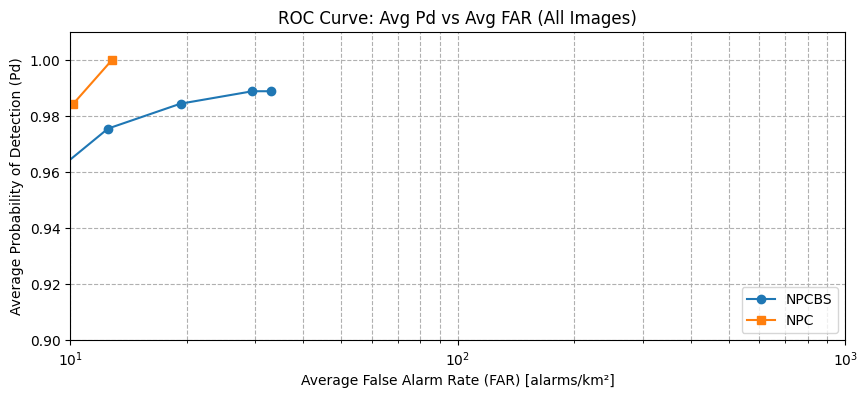

In [64]:
# --- Plotting ROC Curve (Avg Pd vs Avg FAR) ---
plt.figure(figsize=(10, 4))
if avg_npcbs_results:
    npcbs_far, npcbs_pd = zip(*avg_npcbs_results)
    plt.plot(npcbs_far, npcbs_pd, 'o-', label='NPCBS')
if avg_npc_results:
    npc_far, npc_pd = zip(*avg_npc_results)
    plt.plot(npc_far, npc_pd, 's-', label='NPC')
plt.xscale('log')
plt.grid(True, which="both", ls="--")
plt.xlabel('Average False Alarm Rate (FAR) [alarms/km²]')
plt.ylabel('Average Probability of Detection (Pd)')
plt.title('ROC Curve: Avg Pd vs Avg FAR (All Images)')
plt.legend(loc='lower right')
plt.ylim(0.9, 1.01)
plt.xlim(1e+1, 1e3)
plt.show()